In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import torch

if torch.cuda.is_available():
    print("GPU disponibile!")
    print("Nome GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU NON disponibile.")

GPU disponibile!
Nome GPU: Tesla T4


In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/financial_news_base.jsonl"

df = pd.read_json(file_path, lines=True)

df.head()

,date_publish,description,maintext,title,mentioned_companies,related_companies,industries,sentiment,emotion,sentiment_label
0,2018-06-22 18:39:00,Morgan Stanley is telling its clients to pay a...,Morgan Stanley is telling its clients to pay a...,Morgan Stanley sees 'a pattern forming' of the...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.0005622319, 'neutral': 0.006970...","{'neutral': 0.9212942719, 'surprise': 0.039100...",positive
1,2018-11-15 00:00:00,"The FCC voted to grant ""market access"" request...",By David Shepardson\nWASHINGTON (Reuters - The...,"SpaceX, TeleSat Canada bids get U.S. nod to ex...","[TSLA, MU]","[IKGH, CLLS, EBIO, GMAB, GBS, WIMI, WALD, FGEN...","[3674, 9999]","{'negative': 0.0002858295, 'neutral': 0.001688...","{'neutral': 0.8668617606000001, 'joy': 0.05769...",positive
2,2018-12-29 19:57:55,(Bloomberg) -- A lawsuit filed against Google ...,(Bloomberg) -- A lawsuit filed against Google ...,Google Wins Dismissal of Suit Over Facial Reco...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.2307210714, 'neutral': 0.361657...","{'anger': 0.7141016126, 'neutral': 0.202039063...",positive
3,2018-09-12 18:42:40,"With camera upgrades, better screens and more",Apple on Wednesday unveiled a trio of new iPho...,"Apple Unveils iPhone XS, iPhone XS Max and Che...",[AAPL],"[None, TDC, HPQ, SCKT, OMCL, CRAY, ZEPP, IBM, ...",[3571],"{'negative': 0.0053426563, 'neutral': 0.164953...","{'neutral': 0.9592552185000001, 'surprise': 0....",positive
4,2018-04-23 20:03:16,Google is reporting on Monday.,"Google’s (GOOG, GOOGL) parent company Alphabet...",Alphabet Q1 2018 earnings,"[GOOGL, INTC, META, AAPL]","[IGLD, TDC, NSAT, CRAY, TCX, FLEX, SMCI, WBMD,...","[3571, 3679, 7375]","{'negative': 0.0003154654, 'neutral': 5.86179e...","{'neutral': 0.6759750247, 'surprise': 0.166648...",positive


2) Split stratificato

In [5]:
print(df.columns)
print(df[["description","sentiment_label"]].head(1))

Index(['date_publish', 'description', 'maintext', 'title',
       'mentioned_companies', 'related_companies', 'industries', 'sentiment',
       'emotion', 'sentiment_label'],
      dtype='object')
                                         description sentiment_label
0  Morgan Stanley is telling its clients to pay a...        positive


In [22]:
# =========================
# 0) IMPORT
# =========================
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional, Masking, Dropout, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


# =========================
# 1) X, y dal DF
# =========================
# df deve esistere già
X_texts = df["description"].fillna("").astype(str).values

label_map = {"negative": 0, "neutral": 1, "positive": 2}
y = df["sentiment_label"].astype(str).str.lower().map(label_map).values

mask = ~np.isnan(y)
X_texts = X_texts[mask]
y = y[mask].astype("int32")

print("Class counts (0=neg,1=neu,2=pos):", np.bincount(y))

# =========================
# 2) SPLIT train/val/test
# =========================
X_train_texts, X_temp_texts, y_train, y_temp = train_test_split(
    X_texts, y, test_size=0.3, random_state=42, stratify=y
)
X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_temp_texts, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train class balance:", np.bincount(y_train))
print("Val   class balance:", np.bincount(y_val))
print("Test  class balance:", np.bincount(y_test))

# =========================
# 3) TOKENIZER (CAP 50k) + SEQ LEN + PAD
# =========================
VOCAB_SIZE = 50000      # cap vero (include indice 0 padding)
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_texts)

train_seq = tokenizer.texts_to_sequences(X_train_texts)
val_seq   = tokenizer.texts_to_sequences(X_val_texts)
test_seq  = tokenizer.texts_to_sequences(X_test_texts)

lengths = np.array([len(s) for s in train_seq])
print("Seq len percentiles:", np.percentile(lengths, [50, 75, 90, 95, 99, 100]).astype(int))

MAX_SEQUENCE_LEN = int(np.percentile(lengths, 95))
MAX_SEQUENCE_LEN = min(MAX_SEQUENCE_LEN, 256)
MAX_SEQUENCE_LEN = max(MAX_SEQUENCE_LEN, 50)
print("MAX_SEQUENCE_LEN:", MAX_SEQUENCE_LEN)

# padding come nei tuoi esperimenti: pre + truncating post
X_train = pad_sequences(train_seq, maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")
X_val   = pad_sequences(val_seq,   maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")
X_test  = pad_sequences(test_seq,  maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")

y_train = y_train.astype("int32")
y_val   = y_val.astype("int32")
y_test  = y_test.astype("int32")

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())

# sicurezza: nessun indice deve superare VOCAB_SIZE-1
assert int(X_train.max()) < VOCAB_SIZE, f"Indice fuori range: max={X_train.max()} >= VOCAB_SIZE={VOCAB_SIZE}"

# =========================
# 4) CLASS WEIGHTS
# =========================
cw = compute_class_weight(class_weight="balanced", classes=np.array([0,1,2]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1]), 2: float(cw[2])}
print("class_weight_dict:", class_weight_dict)

# =========================
# 5) CARICA GLOVE + EMBEDDING MATRIX
# =========================
EMBED_DIM = 100
glove_path = "/content/glove.6B.100d.txt"  # <-- cambia qui se sta in Drive

# (debug) controlla che esista davvero
import os
print("GloVe exists?", os.path.exists(glove_path))
# Se vuoi vedere i file in /content:
# !ls -lh /content | head

embeddings_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.rstrip().split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded GloVe vectors:", len(embeddings_index))

# embedding_matrix: (VOCAB_SIZE, EMBED_DIM)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype="float32")

# tokenizer.word_index: indici "globali", noi teniamo solo i < VOCAB_SIZE
for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

print("embedding_matrix shape:", embedding_matrix.shape, "dtype:", embedding_matrix.dtype)
# riga 0 resta zero => ok per padding

# =========================
# 6) MODELLO BiLSTM con GloVe (ROBUSTO: Masking layer)
# =========================
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False,         # prima prova frozen (poi puoi mettere True)
        mask_zero=True          # <- IMPORTANT: evitiamo mask_zero che a volte rompe su GPU
    ),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.2)),
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

import tensorflow as tf

def sparse_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=3)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        fl = weight * ce

        return tf.reduce_sum(fl, axis=1)

    return loss

model.compile(
    loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"]
)


model.build(input_shape=(None, MAX_SEQUENCE_LEN))
model.summary()

checkpoint = ModelCheckpoint(
    "best-bilstm-glove.weights.h5",
    monitor="val_loss",
    save_weights_only=True,
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Class counts (0=neg,1=neu,2=pos): [12421 19028 39098]
Train class balance: [ 8695 13319 27368]
Val   class balance: [1863 2854 5865]
Test  class balance: [1863 2855 5865]
Seq len percentiles: [   57    78    96   164  1081 11290]
MAX_SEQUENCE_LEN: 164
X_train shape: (49382, 164) dtype: int32
y_train shape: (49382,) dtype: int32
X_train min/max: 0 49999
class_weight_dict: {0: 1.8931186505654591, 1: 1.235878569462172, 2: 0.6014566890772679}
GloVe exists? True
Loaded GloVe vectors: 400000
embedding_matrix shape: (50000, 100) dtype: float32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 164, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 164, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,092,931 (19.43 MB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

Epoch 1/20
1542/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4454 - loss: 0.1139
Epoch 1: val_loss improved from inf to 0.10273, saving model to best-bilstm-glove.weights.h5
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.4455 - loss: 0.1139 - val_accuracy: 0.5310 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 2/20
1543/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5080 - loss: 0.1009
Epoch 2: val_loss improved from 0.10273 to 0.09158, saving model to best-bilstm-glove.weights.h5
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5081 - loss: 0.1009 - val_accuracy: 0.5729 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 3/20
1543/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5310 - loss: 0.0972
Epoch 3: val_loss did not improve from 0.09158

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5311 - loss: 0.0972 - val_accuracy: 0.5673 - val_loss: 0.0923 - learni

CONFUSION MATRIX + F1

In [28]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predizioni probabilistiche
y_pred_probs = model.predict(X_test)

# Classi predette (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [29]:
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Test Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")


Test Accuracy: 0.5824
Macro F1: 0.5599
Weighted F1: 0.5918


In [30]:
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"],
    digits=4
))


Classification Report:

              precision    recall  f1-score   support

    Negative     0.3916    0.5700    0.4643      1863
     Neutral     0.5166    0.6476    0.5748      2855
    Positive     0.7579    0.5546    0.6405      5865

    accuracy                         0.5824     10583
   macro avg     0.5554    0.5908    0.5599     10583
weighted avg     0.6283    0.5824    0.5918     10583



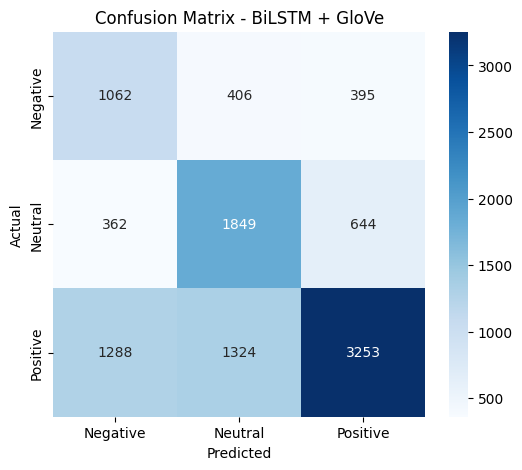

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM + GloVe")
plt.show()